In [ ]:

# TASK 0: SETUP + LOAD DATASET


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# CHANGE THIS IF NEEDED

DATA_PATH = "student_addiction_dataset_train.csv"   # <-- CHANGE THIS PATH IF YOUR FILE NAME/LOCATION IS DIFFERENT
TARGET_COL = "Addiction_Class"

df = pd.read_csv(DATA_PATH)

print("DATASET SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nFIRST 5 ROWS:")
display(df.head())


DATASET SHAPE: (50342, 11)

COLUMNS: ['Experimentation', 'Academic_Performance_Decline', 'Social_Isolation', 'Financial_Issues', 'Physical_Mental_Health_Problems', 'Legal_Consequences', 'Relationship_Strain', 'Risk_Taking_Behavior', 'Withdrawal_Symptoms', 'Denial_and_Resistance_to_Treatment', 'Addiction_Class']

FIRST 5 ROWS:


,Experimentation,Academic_Performance_Decline,Social_Isolation,Financial_Issues,Physical_Mental_Health_Problems,Legal_Consequences,Relationship_Strain,Risk_Taking_Behavior,Withdrawal_Symptoms,Denial_and_Resistance_to_Treatment,Addiction_Class
0,Yes,No,No,Yes,No,No,No,Yes,No,No,No
1,No,Yes,NaN,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes
2,No,No,No,No,No,Yes,Yes,Yes,No,No,No
3,Yes,No,Yes,Yes,No,Yes,No,No,No,Yes,Yes
4,Yes,Yes,No,NaN,No,Yes,Yes,Yes,No,No,Yes


INFO:
<class 'pandas.DataFrame'>
RangeIndex: 50342 entries, 0 to 50341
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Experimentation                     47780 non-null  str  
 1   Academic_Performance_Decline        47844 non-null  str  
 2   Social_Isolation                    47792 non-null  str  
 3   Financial_Issues                    47805 non-null  str  
 4   Physical_Mental_Health_Problems     47888 non-null  str  
 5   Legal_Consequences                  47766 non-null  str  
 6   Relationship_Strain                 47799 non-null  str  
 7   Risk_Taking_Behavior                47765 non-null  str  
 8   Withdrawal_Symptoms                 47730 non-null  str  
 9   Denial_and_Resistance_to_Treatment  47889 non-null  str  
 10  Addiction_Class                     50342 non-null  str  
dtypes: str(11)
memory usage: 4.2 MB

MISSING VALUES PER COLUMN:


Withdrawal_Symptoms                   2612
Risk_Taking_Behavior                  2577
Legal_Consequences                    2576
Experimentation                       2562
Social_Isolation                      2550
Relationship_Strain                   2543
Financial_Issues                      2537
Academic_Performance_Decline          2498
Physical_Mental_Health_Problems       2454
Denial_and_Resistance_to_Treatment    2453
Addiction_Class                          0
dtype: int64


DUPLICATE ROWS: 36586 out of 50342 (72.67%)

TARGET DISTRIBUTION (COUNT):


Addiction_Class
No     35270
Yes    15072
Name: count, dtype: int64


TARGET DISTRIBUTION (PERCENT):


Addiction_Class
No     0.700608
Yes    0.299392
Name: proportion, dtype: float64


DUPLICATES DROPPED: 36586 | NEW SHAPE: (13756, 11)


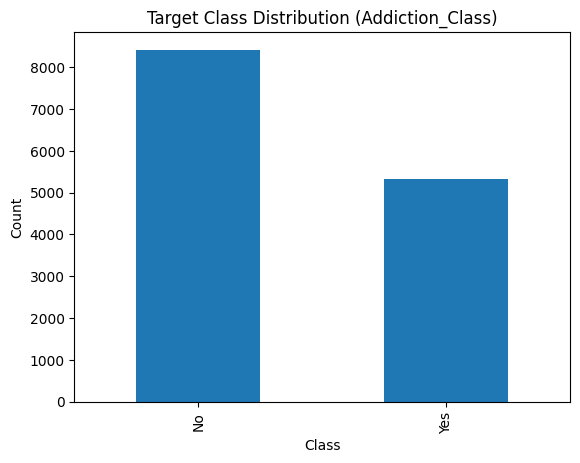

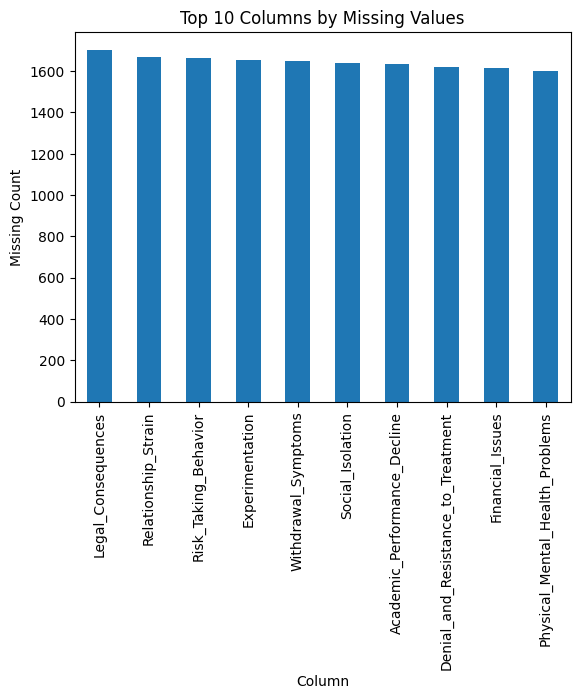

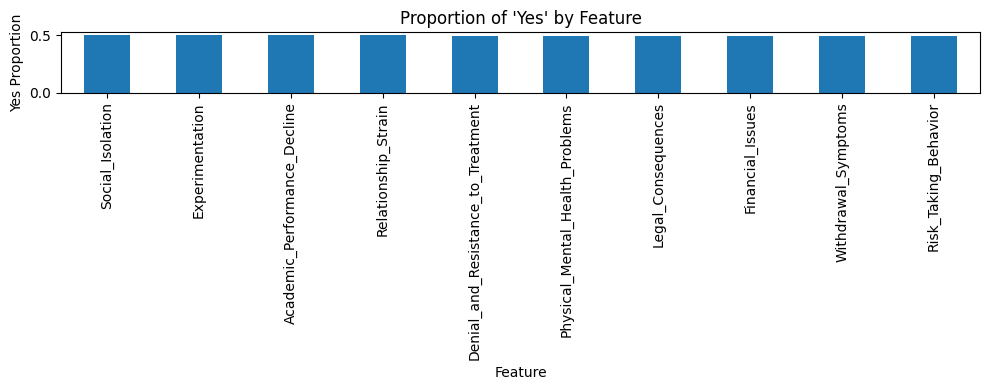


REPORT PROMPTS (WRITE IN YOUR REPORT):
1) Dataset source: where you got it, link, how accessed/downloaded.
2) Creator + date: who created dataset and when (if known).
3) UNSDG alignment: explain which SDG it relates to and why.
4) Feature descriptions: list each column and what it represents.
5) Ask 2–3 questions dataset can answer (e.g., which factors relate to addiction).
6) Data quality: missing values, duplicates, imbalance; why that matters.
7) For each plot: write 2–3 lines explaining what you learned.


In [ ]:

# TASK 1: DATASET UNDERSTANDING + EDA (MANDATORY)
# - Source/creator/access/UNSDG alignment: YOU WRITE IN REPORT (I GIVE PROMPTS BELOW)
# - Feature list + 2-3 questions
# - Missing values, duplicates, class balance
# - Visualizations + insights


print("INFO:")
df.info()

print("\nMISSING VALUES PER COLUMN:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

# Duplicate check
dup_count = df.duplicated().sum()
print("\nDUPLICATE ROWS:", dup_count, "out of", len(df), f"({dup_count/len(df):.2%})")

# Target balance
print("\nTARGET DISTRIBUTION (COUNT):")
display(df[TARGET_COL].value_counts(dropna=False))

print("\nTARGET DISTRIBUTION (PERCENT):")
display(df[TARGET_COL].value_counts(normalize=True, dropna=False))


# BASIC CLEANING CHOICE FOR DUPLICATES

# NOTE FOR REPORT: Explain why you did or did not drop duplicates.
# If duplicates are extremely high, they can make evaluation misleading.
df_eda = df.copy()

# Choose one:
DROP_DUPLICATES = True  # <-- SET False if you want to keep duplicates

if DROP_DUPLICATES:
    before = len(df_eda)
    df_eda = df_eda.drop_duplicates()
    after = len(df_eda)
    print(f"\nDUPLICATES DROPPED: {before-after} | NEW SHAPE: {df_eda.shape}")
else:
    print("\nDUPLICATES KEPT | SHAPE:", df_eda.shape)


# SIMPLE VISUALIZATIONS (YES/NO COUNTS FOR FEATURES)

feature_cols = [c for c in df_eda.columns if c != TARGET_COL]

# Plot: target distribution bar
plt.figure()
df_eda[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target Class Distribution (Addiction_Class)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Plot: missing values bar (top 10)
plt.figure()
missing_eda = df_eda.isna().sum().sort_values(ascending=False).head(10)
missing_eda.plot(kind="bar")
plt.title("Top 10 Columns by Missing Values")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.show()

# Plot: YES rate per feature (how many 'Yes' in each column)
yes_rates = {}
for c in feature_cols:
    # Treat NaN safely; count yes among non-missing
    non_missing = df_eda[c].dropna()
    if len(non_missing) == 0:
        yes_rates[c] = np.nan
    else:
        yes_rates[c] = (non_missing == "Yes").mean()

plt.figure(figsize=(10,4))
pd.Series(yes_rates).sort_values(ascending=False).plot(kind="bar")
plt.title("Proportion of 'Yes' by Feature")
plt.xlabel("Feature")
plt.ylabel("Yes Proportion")
plt.tight_layout()
plt.show()


# REPORT CONTENT PROMPTS (WRITE THESE IN YOUR REPORT)

print("\nREPORT PROMPTS (WRITE IN YOUR REPORT):")
print("1) Dataset source: where you got it, link, how accessed/downloaded.")
print("2) Creator + date: who created dataset and when (if known).")
print("3) UNSDG alignment: explain which SDG it relates to and why.")
print("4) Feature descriptions: list each column and what it represents.")
print("5) Ask 2–3 questions dataset can answer (e.g., which factors relate to addiction).")
print("6) Data quality: missing values, duplicates, imbalance; why that matters.")
print("7) For each plot: write 2–3 lines explaining what you learned.")


In [ ]:

# TASK 2: NEURAL NETWORK CLASSIFIER (FIXED PIPELINE)


import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Use df_eda created in Task 1
df_model = df_eda.copy()

X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ FIX: transformer that works with ndarray OR DataFrame
def yesno_to_numeric(X_in):
    # If ndarray -> convert by string compare
    if isinstance(X_in, np.ndarray):
        # X_in contains strings "Yes"/"No" after imputer
        return (X_in == "Yes").astype(float)

    # If DataFrame
    X_out = X_in.copy()
    for c in X_out.columns:
        X_out[c] = (X_out[c] == "Yes").astype(float)
    return X_out

yesno_transformer = FunctionTransformer(yesno_to_numeric)

nn_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("yesno", yesno_transformer),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

# CV score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_nn = cross_val_score(nn_pipe, X_train, y_train, cv=cv, scoring="f1").mean()

# Train + evaluate
nn_pipe.fit(X_train, y_train)
pred_nn = nn_pipe.predict(X_test)

acc  = accuracy_score(y_test, pred_nn)
prec = precision_score(y_test, pred_nn, zero_division=0)
rec  = recall_score(y_test, pred_nn, zero_division=0)
f1   = f1_score(y_test, pred_nn, zero_division=0)

print("NEURAL NETWORK (MLP) RESULTS")
print("CV F1 Score:", round(cv_f1_nn, 4))
print("Accuracy   :", round(acc, 4))
print("Precision  :", round(prec, 4))
print("Recall     :", round(rec, 4))
print("F1-score   :", round(f1, 4))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_nn))
print("\nClassification Report:\n", classification_report(y_test, pred_nn))


NEURAL NETWORK (MLP) RESULTS
CV F1 Score: 0.0635
Accuracy   : 0.6072
Precision  : 0.2812
Recall     : 0.0084
F1-score   : 0.0164

Confusion Matrix:
 [[1662   23]
 [1058    9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.99      0.75      1685
           1       0.28      0.01      0.02      1067

    accuracy                           0.61      2752
   macro avg       0.45      0.50      0.39      2752
weighted avg       0.48      0.61      0.47      2752



In [ ]:

# TASK 3: TWO CLASSICAL MODELS (NOT NN)
# - Logistic Regression
# - Random Forest
# - Evaluate and compare


# Common preprocessing (impute + yes/no->num)
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("yesno", yesno_transformer),
])

def eval_model(name, model_pipe):
    model_pipe.fit(X_train, y_train)
    pred = model_pipe.predict(X_test)

    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)

    print(f"\n{name}")
    print("Accuracy  :", round(acc, 4))
    print("Precision :", round(prec, 4))
    print("Recall    :", round(rec, 4))
    print("F1-score  :", round(f1, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    return acc, prec, rec, f1

# Logistic Regression pipeline
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Random Forest pipeline
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# CV scores
cv_f1_log = cross_val_score(logreg_pipe, X_train, y_train, cv=cv, scoring="f1").mean()
cv_f1_rf  = cross_val_score(rf_pipe,     X_train, y_train, cv=cv, scoring="f1").mean()

print("CV F1 Logistic Regression:", round(cv_f1_log, 4))
print("CV F1 Random Forest       :", round(cv_f1_rf, 4))

# Test metrics
res_log = eval_model("Logistic Regression", logreg_pipe)
res_rf  = eval_model("Random Forest", rf_pipe)

print("\nTASK 3 REPORT NOTE:")
print("- State which model is better and WHY (based on F1 + confusion matrix, not only accuracy).")


CV F1 Logistic Regression: 0.4364
CV F1 Random Forest       : 0.3325

Logistic Regression
Accuracy  : 0.4942
Precision : 0.3848
Recall    : 0.5089
F1-score  : 0.4383
Confusion Matrix:
 [[817 868]
 [524 543]]

Random Forest
Accuracy  : 0.4379
Precision : 0.3
Recall    : 0.3374
F1-score  : 0.3176
Confusion Matrix:
 [[845 840]
 [707 360]]

TASK 3 REPORT NOTE:
- State which model is better and WHY (based on F1 + confusion matrix, not only accuracy).


In [ ]:

# TASK 4: HYPERPARAMETER TUNING + CROSS-VALIDATION (BOTH MODELS)
# - Use GridSearchCV
# - Report best params + best CV score


# Logistic Regression tuning
logreg_params = {
    "model__C": [0.1, 1, 5, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)
print("BEST Logistic Regression Params:", logreg_grid.best_params_)
print("BEST Logistic Regression CV F1 :", round(logreg_grid.best_score_, 4))

best_logreg = logreg_grid.best_estimator_

# Random Forest tuning
rf_params = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print("\nBEST Random Forest Params:", rf_grid.best_params_)
print("BEST Random Forest CV F1 :", round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_

# Evaluate tuned models on test set
print("\n--- TUNED MODELS TEST RESULTS ---")
_ = eval_model("TUNED Logistic Regression", best_logreg)
_ = eval_model("TUNED Random Forest", best_rf)


C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


BEST Logistic Regression Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
BEST Logistic Regression CV F1 : 0.4365

BEST Random Forest Params: {'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
BEST Random Forest CV F1 : 0.3557

--- TUNED MODELS TEST RESULTS ---

TUNED Logistic Regression
Accuracy  : 0.4942
Precision : 0.3848
Recall    : 0.5089
F1-score  : 0.4383
Confusion Matrix:
 [[817 868]
 [524 543]]


C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



TUNED Random Forest
Accuracy  : 0.4466
Precision : 0.3238
Recall    : 0.3927
F1-score  : 0.3549
Confusion Matrix:
 [[810 875]
 [648 419]]


In [ ]:

# TASK 5: FEATURE SELECTION (WEEK 10) FOR BOTH MODELS
# METHOD: FILTER METHOD -> Mutual Information + SelectKBest
# - Apply to both models
# - Justify in report: keeps top-k informative features


# Choose K features (you can change this after seeing results)
K = min(6, X_train.shape[1])  # safe if dataset has fewer cols
print("Using K =", K, "features out of", X_train.shape[1])

feature_selector = SelectKBest(score_func=mutual_info_classif, k=K)

# Logistic Regression + Feature Selection
logreg_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", feature_selector),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# Random Forest + Feature Selection
rf_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", feature_selector),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

# CV with feature selection
cv_f1_log_fs = cross_val_score(logreg_fs_pipe, X_train, y_train, cv=cv, scoring="f1").mean()
cv_f1_rf_fs  = cross_val_score(rf_fs_pipe,     X_train, y_train, cv=cv, scoring="f1").mean()

print("CV F1 (LogReg + FS):", round(cv_f1_log_fs, 4))
print("CV F1 (RF + FS)    :", round(cv_f1_rf_fs, 4))

# Fit once to extract selected feature names (IMPORTANT for report)
logreg_fs_pipe.fit(X_train, y_train)

# Get feature names after preprocessing (same as original columns after yes/no mapping)
all_features = X_train.columns.to_list()
mask = logreg_fs_pipe.named_steps["select"].get_support()
selected_features = [f for f, keep in zip(all_features, mask) if keep]

print("\nSELECTED FEATURES (Task 5):")
print(selected_features)

print("\n--- TEST RESULTS WITH FEATURE SELECTION ---")
_ = eval_model("LogReg + Feature Selection", logreg_fs_pipe)
_ = eval_model("RF + Feature Selection", rf_fs_pipe)

print("\nTASK 5 REPORT NOTE:")
print("- Explain why you used Mutual Information (filter method).")
print("- Mention the selected features list and why they might matter.")


Using K = 6 features out of 10
CV F1 (LogReg + FS): 0.4361
CV F1 (RF + FS)    : 0.4019

SELECTED FEATURES (Task 5):
['Academic_Performance_Decline', 'Social_Isolation', 'Legal_Consequences', 'Risk_Taking_Behavior', 'Withdrawal_Symptoms', 'Denial_and_Resistance_to_Treatment']

--- TEST RESULTS WITH FEATURE SELECTION ---

LogReg + Feature Selection
Accuracy  : 0.5018
Precision : 0.3899
Recall    : 0.5042
F1-score  : 0.4397
Confusion Matrix:
 [[843 842]
 [529 538]]

RF + Feature Selection
Accuracy  : 0.5007
Precision : 0.3755
Recall    : 0.4339
F1-score  : 0.4026
Confusion Matrix:
 [[915 770]
 [604 463]]

TASK 5 REPORT NOTE:
- Explain why you used Mutual Information (filter method).
- Mention the selected features list and why they might matter.


In [ ]:

# TASK 6: FINAL MODELS = TUNED + SELECTED FEATURES
# - Rebuild both models using:
#   (a) best hyperparameters (Task 4)
#   (b) selected features (Task 5)
# - Evaluate on test set
# - Create a comparison table (MANDATORY)

# Build "final" tuned models + feature selection
final_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(mutual_info_classif, k=K)),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        C=logreg_grid.best_params_["model__C"],
        penalty="l2",
        solver="lbfgs"
    ))
])

final_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(mutual_info_classif, k=K)),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        n_estimators=rf_grid.best_params_["model__n_estimators"],
        max_depth=rf_grid.best_params_["model__max_depth"],
        min_samples_split=rf_grid.best_params_["model__min_samples_split"],
        min_samples_leaf=rf_grid.best_params_["model__min_samples_leaf"]
    ))
])

def metrics_row(name, pipe, cv_score):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        "Model": name,
        "CV_F1": round(cv_score, 4),
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4)
    }

cv_f1_final_log = cross_val_score(final_logreg, X_train, y_train, cv=cv, scoring="f1").mean()
cv_f1_final_rf  = cross_val_score(final_rf,     X_train, y_train, cv=cv, scoring="f1").mean()

rows = []
rows.append(metrics_row("FINAL Logistic Regression (Tuned+FS)", final_logreg, cv_f1_final_log))
rows.append(metrics_row("FINAL Random Forest (Tuned+FS)",       final_rf,     cv_f1_final_rf))

results_table = pd.DataFrame(rows)
display(results_table)

print("\nSELECTED FEATURES USED (K features):", selected_features)

print("\nFINAL Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, final_logreg.predict(X_test)))

print("\nFINAL Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, final_rf.predict(X_test)))


C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bista\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

,Model,CV_F1,Accuracy,Precision,Recall,F1
0,FINAL Logistic Regression (Tuned+FS),0.4452,0.4985,0.3932,0.5398,0.4550
1,FINAL Random Forest (Tuned+FS),0.4155,0.4880,0.3766,0.4892,0.4256



SELECTED FEATURES USED (K features): ['Academic_Performance_Decline', 'Social_Isolation', 'Legal_Consequences', 'Risk_Taking_Behavior', 'Withdrawal_Symptoms', 'Denial_and_Resistance_to_Treatment']

FINAL Logistic Regression Confusion Matrix:
[[796 889]
 [491 576]]

FINAL Random Forest Confusion Matrix:
[[821 864]
 [545 522]]
